In [64]:
import pandas as pd
import numpy as np
import os 
import datetime
from pathlib import Path
import glob
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


In [2]:
options_hourly_data_dir = Path("binance_vision_data_options")
csv_files = sorted(options_hourly_data_dir.glob("BTCUSDT-EOHSummary-*.csv"))
option_hourly_dfs = []
for path in csv_files:
    df = pd.read_csv(path)
    option_hourly_dfs.append(df)

In [3]:
option_eods = []
for df in option_hourly_dfs:
    df_call_eod = df[
    (df['type']=='C') &
    (df['hour']  == 23)
    ].reset_index(drop=True)
    option_eods.append(df_call_eod)


In [49]:
option_eods_df = pd.concat(option_eods, ignore_index=True)
# full dataset with grid of strikes for each expiry (EOD data for options)
option_eods_df.head()

,date,hour,symbol,underlying,type,strike,open,high,low,close,...,best_buy_iv,best_sell_iv,mark_price,mark_iv,delta,gamma,vega,theta,openinterest_contracts,openinterest_usdt
0,2023-05-18,23,BTC-230728-32000-C,BTCUSDT,C,230728-32000,875.0,875.0,875.0,875.0,...,NaN,0.473889,649.0,0.468222,0.224863,0.000054,35.300777,-11.750201,3.14,8.424843e+04
1,2023-05-18,23,BTC-230519-26750-C,BTCUSDT,C,230519-26750,415.0,415.0,75.0,200.0,...,NaN,0.419437,164.0,0.387619,0.594105,0.001234,3.143430,-182.761394,41.80,1.121524e+06
2,2023-05-18,23,BTC-240329-35000-C,BTCUSDT,C,240329-35000,3485.0,3485.0,3485.0,3485.0,...,NaN,0.537457,2687.0,0.522445,0.380120,0.000029,94.936177,-7.864521,2.28,6.117402e+04
3,2023-05-18,23,BTC-230929-15000-C,BTCUSDT,C,230929-15000,0.0,0.0,0.0,0.0,...,NaN,1.067505,12185.0,0.720444,0.939727,0.000010,19.380578,-5.235980,0.00,0.000000e+00
4,2023-05-18,23,BTC-230630-45000-C,BTCUSDT,C,230630-45000,70.0,70.0,70.0,70.0,...,NaN,0.723398,44.0,0.701103,0.020299,0.000008,4.479017,-3.708956,59.37,1.592939e+06


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\

In [5]:
spot_daily_data_dir = Path("binance_vision_data_spot")
csv_files = sorted(spot_daily_data_dir.glob("BTCUSDT-1d-*.csv"))
spot_daily_dfs = []
for path in csv_files:
    df = pd.read_csv(path)
    spot_daily_dfs.append(df)

In [6]:
processed_spot_dfs = []
for df in spot_daily_dfs:
    df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], unit='ms')\
                         .dt.strftime('%Y-%m-%d')

    cols = [
        'open_time','open','high','low','close','volume',
        'close_time','quote_asset_volume','number_of_trades',
        'taker_buy_base_asset_volume','taker_buy_quote_asset_volume','ignore'
    ]
    df.columns = cols

    df['close_time'] = pd.to_datetime(df['close_time'], unit='ms').dt.strftime('%Y-%m-%d')
    processed_spot_dfs.append(df)



In [39]:
processed_spot_dfs[0].head()
spot_data = pd.concat(processed_spot_dfs, ignore_index=True)
spot_data.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
0,2023-05-02,28068.26,28879.88,27872.00,28669.86,50824.52240,2023-05-02,1.441734e+09,1174697,24789.36748,7.032068e+08,0
1,2023-05-03,28669.85,29266.66,28113.69,29026.16,64615.79213,2023-05-03,1.845961e+09,1502909,32291.20998,9.225500e+08,0
2,2023-05-04,29026.16,29379.83,28663.64,28838.16,42575.47501,2023-05-04,1.233816e+09,961542,20470.21240,5.932814e+08,0
3,2023-05-05,28838.16,29677.00,28800.00,29505.61,58415.83048,2023-05-05,1.709787e+09,1288027,29071.98606,8.509753e+08,0
4,2023-05-06,29505.60,29820.00,28300.00,28848.20,49249.28459,2023-05-06,1.429518e+09,1221021,23315.95073,6.767173e+08,0


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}


In [40]:
option_eods_df['date'] = pd.to_datetime(
    option_eods_df['date'], errors='coerce'
)
option_eods_df['date'] = option_eods_df['date'].dt.date

spot_data['close_time'] = pd.to_datetime(
    spot_data['close_time'], errors='coerce'
)

spot_data['spot_close'] = spot_data['close']
spot_data.drop(columns=['close'], inplace=True)

spot_data['date'] = spot_data['close_time'].dt.date

spot_data_date_and_close = spot_data[['date', 'spot_close']].copy()

full_df = option_eods_df.merge(
    spot_data_date_and_close,
    on='date',
    how='left',
    validate='many_to_one',   # many options → one spot
    indicator=True
)

10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}


In [55]:
full_df.columns

Index(['date', 'hour', 'symbol', 'underlying', 'type', 'strike', 'open',
       'high', 'low', 'close', 'volume_contracts', 'volume_usdt',
       'best_bid_price', 'best_ask_price', 'best_bid_qty', 'best_ask_qty',
       'best_buy_iv', 'best_sell_iv', 'mark_price', 'mark_iv', 'delta',
       'gamma', 'vega', 'theta', 'openinterest_contracts', 'openinterest_usdt',
       'spot_close', '_merge', 'strike_price', 'moneyness', 'expiry', 'T'],
      dtype='object')

In [42]:
# convert strike to numeric 
full_df['strike_price'] = (
    full_df['strike']
      .str.extract(r'-(\d+)$')   # capture the digits after the dash at end of string
      .astype(float)
)


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}


In [46]:
# create moneyness column
full_df['moneyness'] = full_df['strike_price'] / full_df['spot_close']

16588

In [53]:
# create expiry column
full_df['expiry'] = pd.to_datetime(
    full_df['symbol'].str.split('-', expand=True)[1],
    format='%y%m%d',
    errors='coerce'
)

full_df['date'] = pd.to_datetime(full_df['date'])

delta = full_df['expiry'] - full_df['date']
full_df['T'] = delta.dt.days / 365
full_df[['symbol','date','expiry','T']].describe()

,date,expiry,T
count,16588,16588,16588.000000
mean,2023-07-29 22:18:25.956112640,2023-10-18 13:19:10.229081088,0.220892
min,2023-05-18 00:00:00,2023-05-19 00:00:00,0.002740
25%,2023-06-19 00:00:00,2023-07-21 00:00:00,0.021918
50%,2023-07-22 00:00:00,2023-09-29 00:00:00,0.090411
75%,2023-09-04 00:00:00,2023-12-29 00:00:00,0.328767
max,2023-10-23 00:00:00,2024-09-27 00:00:00,1.000000
std,NaN,NaN,0.274289


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\

In [58]:
# clean data for relevant info 
final_data = full_df[['date', 'symbol', 'T', 'moneyness', 'mark_iv']]
final_data.head()

,date,symbol,T,moneyness,mark_iv
0,2023-05-18,BTC-230728-32000-C,0.194521,1.193083,0.468222
1,2023-05-18,BTC-230519-26750-C,0.002740,0.997342,0.387619
2,2023-05-18,BTC-240329-35000-C,0.865753,1.304934,0.522445
3,2023-05-18,BTC-230929-15000-C,0.367123,0.559257,0.720444
4,2023-05-18,BTC-230630-45000-C,0.117808,1.677772,0.701103


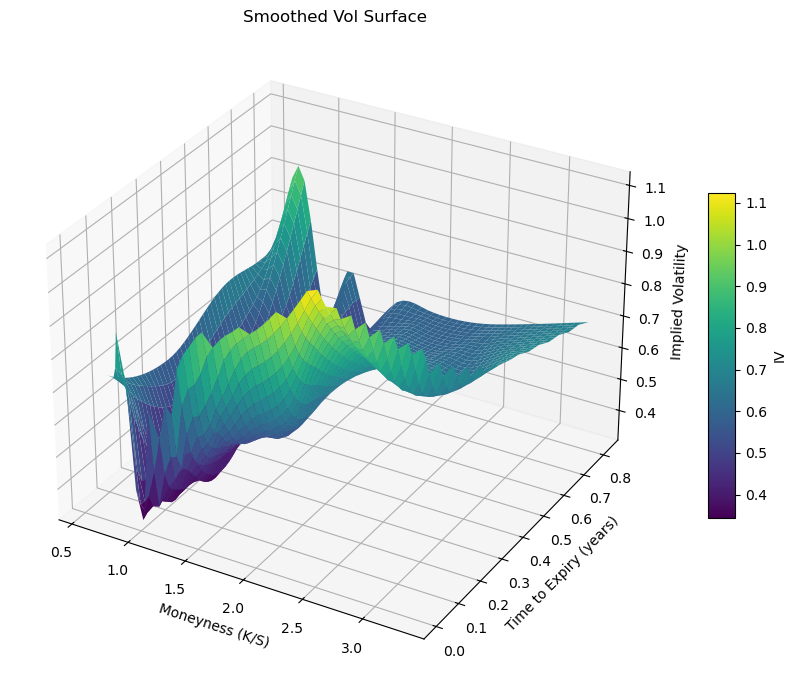

In [74]:
df = final_data[final_data['date'] == '2023-06-05']

T_vals         = df['T'].values
moneyness_vals = df['moneyness'].values
iv_vals        = df['mark_iv'].values

#build a regular grid
nx, ny = 50, 50
T_lin = np.linspace(T_vals.min(),T_vals.max(),nx)
M_lin = np.linspace(moneyness_vals.min(), moneyness_vals.max(), ny)
T_grid, M_grid = np.meshgrid(T_lin, M_lin)

#interpolate onto it
IV_grid = griddata(
    (T_vals, moneyness_vals),
    iv_vals,
    (T_grid, M_grid),
    method='cubic'
)

# plot with a colormap
fig = plt.figure(figsize=(10,7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    M_grid, T_grid, IV_grid,
    rstride=1,
    cstride=1,
    cmap='viridis',       
    edgecolor='none',
    antialiased=True
)

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Time to Expiry (years)')
ax.set_zlabel('Implied Volatility')
ax.set_title('Smoothed Vol Surface')

# tweak view if you like
ax.view_init(elev=30, azim=-60)

fig.colorbar(surf, shrink=0.5, aspect=12, label='IV')
plt.tight_layout()
plt.show()